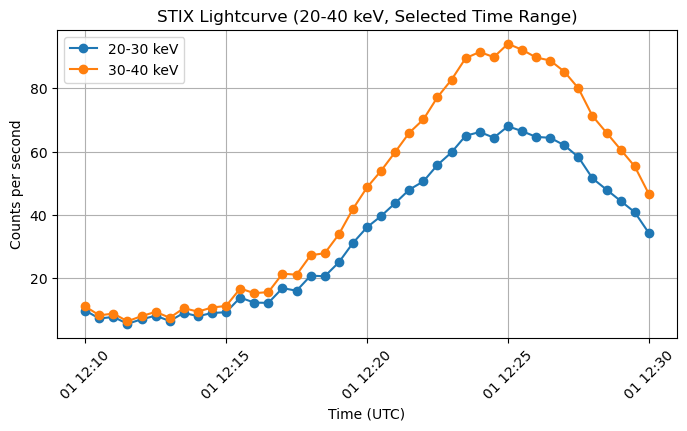

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Generate a time range (simulating observation times)
time_range = np.array([datetime.datetime(2025, 4, 1, 12, 0) + datetime.timedelta(seconds=i*30) for i in range(100)])

# Simulated lightcurve data for different energy bands
np.random.seed(42)
baseline = np.random.normal(5, 1, size=len(time_range))

# Simulating a solar flare event
flare_peak = np.exp(-0.5 * ((np.arange(len(time_range)) - 50) / 8)**2) * 20  

# Energy bands (simulated values)
energy_bands = {
    "4-10 keV": baseline + flare_peak,
    "10-20 keV": (baseline + flare_peak * 1.5) * 1.2,
    "20-30 keV": (baseline + flare_peak * 2) * 1.5,
    "30-40 keV": (baseline + flare_peak * 2.5) * 1.7,
    "40-50 keV": (baseline + flare_peak * 3) * 2.0
}

# Define specific time range (e.g., 12:10 - 12:30 UTC)
start_time = datetime.datetime(2025, 4, 1, 12, 10)
end_time = datetime.datetime(2025, 4, 1, 12, 30)

# Select data within the specified time range
mask = (time_range >= start_time) & (time_range <= end_time)
selected_times = time_range[mask]

# Define the desired energy range (e.g., 20-40 keV)
selected_energy_bands = ["20-30 keV", "30-40 keV"]

# Extract data for selected energy range
selected_data = {band: energy_bands[band][mask] for band in selected_energy_bands}

# Plot the selected data
plt.figure(figsize=(8, 4))
for band, counts in selected_data.items():
    plt.plot(selected_times, counts, label=band, marker='o')

plt.xlabel("Time (UTC)")
plt.ylabel("Counts per second")
plt.title("STIX Lightcurve (20-40 keV, Selected Time Range)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [ ]:
from sunpy.net import Fido, attrs as a
from stixpy.net.client import STIXClient  # This registers the STIX client with Fido

start_time = "2024-05-14T04:00:00"
end_time = "2024-05-14T06:00:00"

ql_query = Fido.search(a.Time(start_time, end_time), 
                       a.Instrument.stix,
                       a.stix.DataProduct.ql_lightcurve)
ql_query


Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
Time,Time,str4,str2,str2,str13,str3,str1
2024-05-14 00:00:00.000,2024-05-14 23:59:59.999,STIX,L1,QL,ql-lightcurve,V02,-


In [ ]:
from sunpy.timeseries import TimeSeries
from stixpy.timeseries.quicklook import STIXQLLightCurve
import matplotlib.pyplot as plt
import datetime

# Path to the STIX Quicklook FITS file
ql_file = "/home/jashhwanth/Desktop/solarflare/14_MAY_2024/STIX DATA/solo_L1_stix-ql-lightcurve_20240514_V02.fits"  # Replace with the actual file path

# Load the Quicklook lightcurve
ql_lightcurves = STIXQLLightCurve.from_fits(ql_file)

# Convert time to datetime format
times = ql_lightcurves.index.to_pydatetime()

# Define the specific time range (e.g., 12:10 - 12:30 UTC)
start_time = datetime.datetime(2024, 5, 14, 1, 30)
end_time = datetime.datetime(2024, 5, 14, 2, 30)

# Select data within the time range
time_mask = (times >= start_time) & (times <= end_time)
selected_times = times[time_mask]

# Define the desired energy range (e.g., 20-40 keV)
selected_energy_bands = ["50-84 keV"]  # Modify as needed

# Extract data for selected energy bands
selected_data = {band: ql_lightcurves[band][time_mask] for band in selected_energy_bands}

# Plot the selected data
plt.figure(figsize=(8, 4))
for band, counts in selected_data.items():
    plt.plot(selected_times, counts, label=band, marker='o')

plt.xlabel("Time (UTC)")
plt.ylabel("Counts per second")
plt.title(f"STIX Lightcurve ({', '.join(selected_energy_bands)}, Selected Time Range)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



ImportError: cannot import name 'STIXQLLightCurve' from 'stixpy.timeseries.quicklook' (/home/jashhwanth/anaconda3/envs/solarflare/lib/python3.12/site-packages/stixpy/timeseries/quicklook.py)

In [3]:
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook  # Registers STIX timeseries with SunPy
import matplotlib.pyplot as plt
import datetime

# Path to the STIX Quicklook FITS file
ql_file = "/home/jashhwanth/Desktop/solarflare/14_MAY_2024/STIX DATA/solo_L1_stix-ql-lightcurve_20240514_V02.fits"  # Replace with the actual file path

# Load the Quicklook lightcurve
ql_lightcurves = TimeSeries.from_fits(ql_file)

# Convert time to datetime format
times = ql_lightcurves.index.to_pydatetime()

# Define the specific time range (e.g., 12:10 - 12:30 UTC)
start_time = datetime.datetime(2025, 4, 1, 12, 10)
end_time = datetime.datetime(2025, 4, 1, 12, 30)

# Select data within the time range
time_mask = (times >= start_time) & (times <= end_time)
selected_times = times[time_mask]

# Define the desired energy range (e.g., 20-40 keV)
selected_energy_bands = ["20-30 keV", "30-40 keV"]  # Modify as needed

# Extract data for selected energy bands
selected_data = {band: ql_lightcurves[band][time_mask] for band in selected_energy_bands}

# Plot the selected data
plt.figure(figsize=(8, 4))
for band, counts in selected_data.items():
    plt.plot(selected_times, counts, label=band, marker='o')

plt.xlabel("Time (UTC)")
plt.ylabel("Counts per second")
plt.title(f"STIX Lightcurve ({', '.join(selected_energy_bands)}, Selected Time Range)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


AttributeError: 'TimeSeriesFactory' object has no attribute 'from_fits'

In [4]:
from sunpy.timeseries import TimeSeries
from stixpy.timeseries import quicklook  # Registers STIX timeseries with SunPy
import matplotlib.pyplot as plt
import datetime

# Path to the STIX Quicklook FITS file
ql_file = "/home/jashhwanth/Desktop/solarflare/14_MAY_2024/STIX DATA/solo_L1_stix-ql-lightcurve_20240514_V02.fits"  # Replace with actual file path

# Load the Quicklook lightcurve
ql_lightcurves = TimeSeries(ql_file)  # Correct way to load FITS file

# Convert time index to datetime format
times = ql_lightcurves.index.to_pydatetime()

# Define the specific time range (e.g., 12:10 - 12:30 UTC)
start_time = datetime.datetime(2025, 4, 1, 12, 10)
end_time = datetime.datetime(2025, 4, 1, 12, 30)

# Select data within the time range
time_mask = (times >= start_time) & (times <= end_time)
selected_times = times[time_mask]

# Define the desired energy range (e.g., 20-40 keV)
selected_energy_bands = ["20-30 keV", "30-40 keV"]  # Modify as needed

# Extract data for selected energy bands
selected_data = {band: ql_lightcurves.quantity(ql_lightcurves.columns[band])[time_mask] for band in selected_energy_bands}

# Plot the selected data
plt.figure(figsize=(8, 4))
for band, counts in selected_data.items():
    plt.plot(selected_times, counts, label=band, marker='o')

plt.xlabel("Time (UTC)")
plt.ylabel("Counts per second")
plt.title(f"STIX Lightcurve ({', '.join(selected_energy_bands)}, Selected Time Range)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


AttributeError: 'QLLightCurve' object has no attribute 'index'

In [6]:
from sunpy.timeseries import TimeSeries
from stixpy.timeseries.quicklook import QLLightCurve
import matplotlib.pyplot as plt
import datetime

# Path to the STIX Quicklook FITS file
ql_file = "/home/jashhwanth/Desktop/solarflare/14_MAY_2024/STIX DATA/solo_L1_stix-ql-lightcurve_20240514_V02.fits"  # Replace with actual file path

# Load the Quicklook lightcurve
ql_lightcurves = TimeSeries(ql_file)  # Correct method to load data

# Get time array
times = ql_lightcurves.data.axes[0]  # Time axis

# Define the specific time range (e.g., 12:10 - 12:30 UTC)
start_time = datetime.datetime(2024, 5, 14, 1, 30)
end_time = datetime.datetime(2024, 5, 14, 2, 30)

# Select data within the time range
time_mask = (times >= start_time) & (times <= end_time)
selected_times = times[time_mask]

# Print available energy bands to check their names
print("Available energy bands:", ql_lightcurves.data.coords['energy'].values)

# Define the desired energy range (e.g., 20-40 keV)
energy_mask = (ql_lightcurves.data.coords['energy'] >= 20) & (ql_lightcurves.data.coords['energy'] <= 40)
selected_energy_data = ql_lightcurves.data.values[time_mask][:, energy_mask]

# Plot the selected data
plt.figure(figsize=(8, 4))
plt.plot(selected_times, selected_energy_data.mean(axis=1), label="20-40 keV", marker='o')

plt.xlabel("Time (UTC)")
plt.ylabel("Counts per second")
plt.title("STIX Lightcurve (20-40 keV, Selected Time Range)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


AttributeError: 'DataFrame' object has no attribute 'coords'